In [1]:
# pip install gensim

In [2]:
import gensim.downloader as api

wiki_model = api.load('glove-wiki-gigaword-50')  # Load the GloVe model with 100-dimensional embeddings

In [3]:
# wiki_model.vector_size

In [4]:
banana_v= wiki_model['banana'] 
apple_v = wiki_model['apple']
lemon_v = wiki_model['lemon']
rahul_v = wiki_model['rahul']
mumbai_v = wiki_model['mumbai']
dhoni_v = wiki_model['dhoni']
 # Get the embedding vector for the word 'banana'

In [5]:
# pip install scikit-learn

In [6]:
from sklearn.metrics.pairwise import cosine_similarity


cosine_similarity([banana_v], [apple_v])

array([[0.5607928]], dtype=float32)

In [7]:
cosine_similarity([banana_v], [lemon_v])

array([[0.6249516]], dtype=float32)

In [8]:
cosine_similarity([rahul_v], [lemon_v])

array([[-0.12388498]], dtype=float32)

In [9]:
cosine_similarity([rahul_v], [dhoni_v])

array([[0.8356801]], dtype=float32)

In [10]:
# rahul_v

In [11]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

In [12]:
points_2d = pca.fit_transform([banana_v, apple_v, lemon_v, rahul_v, mumbai_v, dhoni_v])

In [13]:
points_2d

array([[-3.06220578,  0.20649995],
       [-3.19250679, -1.09023779],
       [-3.72058489,  1.68057339],
       [ 3.84767955,  1.16963426],
       [ 2.29694081, -4.19694238],
       [ 3.8306771 ,  2.23047256]])

In [14]:
# pip install matplotlib

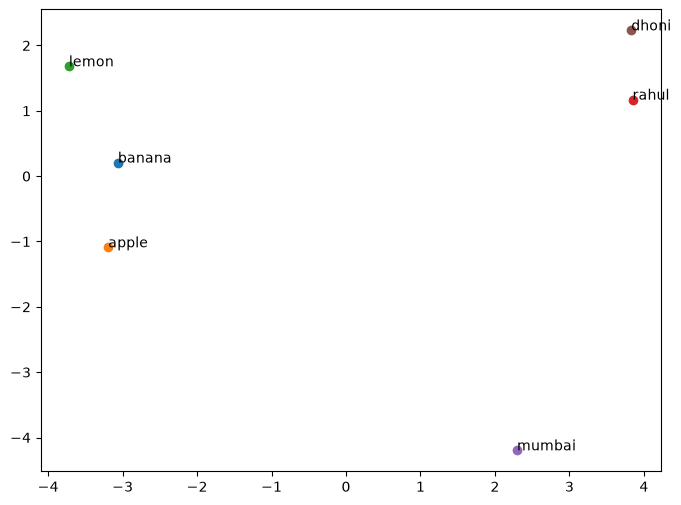

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))


for i, word in enumerate(['banana', 'apple', 'lemon', 'rahul', 'mumbai', 'dhoni']):
    x = points_2d[i, 0]
    y = points_2d[i, 1]
    plt.scatter(x, y)
    plt.text(x, y, word, fontsize=10)




In [16]:
words = ["good", "bad", "happy", "sad", "angry", "joyful", "miserable", "excited", "depressed", "content","loan",'credit','finance']
word_vectors = [wiki_model[word] for word in words]

In [17]:
word_vectors[0]

array([-3.5586e-01,  5.2130e-01, -6.1070e-01, -3.0131e-01,  9.4862e-01,
       -3.1539e-01, -5.9831e-01,  1.2188e-01, -3.1943e-02,  5.5695e-01,
       -1.0621e-01,  6.3399e-01, -4.7340e-01, -7.5895e-02,  3.8247e-01,
        8.1569e-02,  8.2214e-01,  2.2220e-01, -8.3764e-03, -7.6620e-01,
       -5.6253e-01,  6.1759e-01,  2.0292e-01, -4.8598e-02,  8.7815e-01,
       -1.6549e+00, -7.7418e-01,  1.5435e-01,  9.4823e-01, -3.9520e-01,
        3.7302e+00,  8.2855e-01, -1.4104e-01,  1.6395e-02,  2.1115e-01,
       -3.6085e-02, -1.5587e-01,  8.6583e-01,  2.6309e-01, -7.1015e-01,
       -3.6770e-02,  1.8282e-03, -1.7704e-01,  2.7032e-01,  1.1026e-01,
        1.4133e-01, -5.7322e-02,  2.7207e-01,  3.1305e-01,  9.2771e-01],
      dtype=float32)

In [18]:
points_2d = pca.fit_transform(word_vectors)

In [19]:
points_2d

array([[ 0.18549545,  1.03075844],
       [-0.19549221, -0.63958763],
       [ 1.61821096,  0.32838248],
       [ 2.44283495, -1.0849278 ],
       [ 1.34884576, -0.24965914],
       [ 3.18219887,  0.37131297],
       [ 1.54009862, -1.65366331],
       [ 2.13323706,  0.95009857],
       [ 0.40578753, -1.38969056],
       [-1.18697818,  4.07167099],
       [-4.21667599, -0.73979487],
       [-3.30539033, -0.2732565 ],
       [-3.9521725 , -0.72164364]])

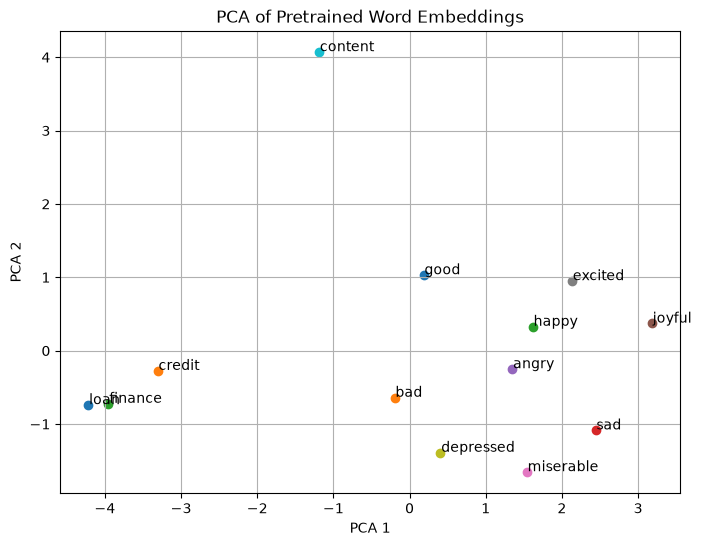

In [20]:
import matplotlib.pyplot as plt

plt
plt.figure(figsize=(8, 6))
for i, word in enumerate(words):
    x = points_2d[i, 0]
    y = points_2d[i, 1]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word, fontsize=10)

plt.title("PCA of Pretrained Word Embeddings")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

In [21]:
DOCS = [
    "Gold loan foreclosure attracts 2% penalty if closed within 6 months of disbursal. No penalty after 6 months.",
    "Personal loan EMI is auto-debited on the 5th of every month. Insufficient funds attract a late fee of Rs 1000.",
    "Customers with CIBIL score below 650 are ineligible for a new personal loan or top-up loan.",
    "Loan renewal is available for Tier 1 and Tier 2 city customers with repayment score above 700 and no defaults in last 12 months.",
    "Gold loan renewal maximum is Rs 1,00,000 for salaried customers and Rs 50,000 for self-employed customers.",
    # add some irrelvent topics here
    "The quick brown fox jumps over the lazy dog.",
    "Artificial intelligence is transforming the tech industry.",
    "Machine learning is a subset of AI.",
    "Deep learning is a specialized form of machine learning.",
    "Natural language processing enables machines to understand human language.",
    "Machine learning needs maths understanding."
]

In [22]:
import numpy as np

def average_word_vectors(docs,model):
    avg_vectors = []
    for doc in docs:
        words = doc.split()
        word_vects = [model[word] for word in words if word in model]
        if word_vects:
            avg_vectors.append(np.mean(word_vects, axis=0))

        else:
            avg_vectors.append(np.zeros(model.vector_size))

    return np.array(avg_vectors)

In [23]:
vector_stores = average_word_vectors(DOCS, wiki_model)

In [24]:
# search function
def search(query, vectors_store, model, docs, top_n=3):
    similarities = cosine_similarity([query], vectors_store)[0]
    top_indices = similarities.argsort()[-top_n:][::-1]
    return [(docs[i], similarities[i]) for i in top_indices]


In [25]:
def query_vector_fn(query, model):
    avg_vector = np.zeros(model.vector_size)
    for word in query.split():
        if word in model:
            avg_vector += model[word]
    return avg_vector / len(query.split())

In [49]:
query = "what is machine learning"
query = query_vector_fn(query, wiki_model)

In [27]:
query

array([ 0.12963858,  0.38462442, -0.06666671,  0.22707871,  0.27871715,
        0.32225301, -0.21761945, -0.09910414,  0.03118   ,  0.22416314,
       -0.008206  ,  0.26572543, -0.33636414, -0.45119857,  0.72615428,
        0.046715  ,  0.17847058,  0.03401771, -0.25803857, -0.23438713,
        0.31650573, -0.06832857,  0.02301228, -0.17817199, -0.37806428,
       -1.5851614 , -0.03555385,  0.09095229,  0.05193443, -0.298679  ,
        2.63421427, -0.0070485 , -0.09093713, -0.16269284,  0.20120499,
       -0.07571572,  0.01605261,  0.09549329,  0.11597628, -0.5723257 ,
       -0.01779404,  0.08858715,  0.30757986,  0.10986643, -0.13328458,
       -0.24801086, -0.211282  ,  0.26748572,  0.16098185, -0.112828  ])

In [50]:
search_results = search(query, vector_stores, wiki_model, DOCS)

In [51]:
search_results

[('Deep learning is a specialized form of machine learning.',
  np.float64(0.9386263027104795)),
 ('Machine learning is a subset of AI.', np.float64(0.9170275054537638)),
 ('Natural language processing enables machines to understand human language.',
  np.float64(0.8943974674236383))]

In [30]:
len(DOCS)

11

In [31]:
len(vector_stores)

11

In [32]:
import numpy as np
v1 = np.array([2,7])
v2 = np.array([3,4])

avg_vector = np.mean([v1, v2], axis=1)





In [33]:
avg_vector

array([4.5, 3.5])

## Sentence transformer based model

In [35]:
# pip install sentence_transformers

In [36]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9806.67it/s]


In [44]:
DOCS = [
    "Gold loan foreclosure attracts 2% penalty if closed within 6 months of disbursal. No penalty after 6 months.",
    "Personal loan EMI is auto-debited on the 5th of every month. Insufficient funds attract a late fee of Rs 1000.",
    "Customers with CIBIL score below 650 are ineligible for a new personal loan or top-up loan.",
    "Loan renewal is available for Tier 1 and Tier 2 city customers with repayment score above 700 and no defaults in last 12 months.",
    "Gold loan renewal maximum is Rs 1,00,000 for salaried customers and Rs 50,000 for self-employed customers.",
    # add some irrelvent topics here
    "The quick brown fox jumps over the lazy dog.",
    "Artificial intelligence is transforming the tech industry.",
    "Machine learning is a subset of AI.",
    "Deep learning is a specialized form of machine learning.",
    "Natural language processing enables machines to understand human language.",
    "Machine learning needs maths understanding."
]

vector_store = model.encode(DOCS)

In [54]:
len(vector_store[0])

384

In [45]:
len(vector_store)

11

In [46]:
from sklearn.metrics.pairwise import cosine_similarity
def search_sentence_transformers(query, vector_store, top_k=5):
    query_vector = model.encode(query)
    similarities = cosine_similarity([query_vector], vector_store)
    top_k_indices = similarities[0].argsort()[-top_k:][::-1]
    # return the top_k most similar documents
    return [DOCS[i] for i in top_k_indices]

In [47]:
query = "what is machine learning"
search_results = search_sentence_transformers(query, vector_store)

In [48]:
search_results

['Machine learning is a subset of AI.',
 'Deep learning is a specialized form of machine learning.',
 'Machine learning needs maths understanding.',
 'Artificial intelligence is transforming the tech industry.',
 'Natural language processing enables machines to understand human language.']

In [38]:
# all-mpnet-base-v2
# model_v2 = SentenceTransformer('all-mpnet-base-v2')


In [ ]:
# len(model.encode('dhoni'))

384

In [ ]:
# model.encode('dhoni')

array([-3.36993411e-02,  1.23391211e-01, -1.89816707e-03,  1.35811027e-02,
       -8.42036828e-02,  1.71557944e-02,  5.59924319e-02,  8.99540558e-02,
        1.28918039e-02,  1.40243499e-02,  7.11536640e-03, -7.93548748e-02,
       -4.24183719e-02,  8.64821970e-02,  4.27068025e-02,  1.39672169e-02,
        1.19684972e-02,  6.23182394e-02,  4.01592068e-02, -5.09022623e-02,
       -2.36569960e-02,  2.99076978e-02, -4.18718681e-02, -4.24903110e-02,
        4.29338403e-02,  4.48211916e-02,  1.16467783e-02,  7.27169886e-02,
       -3.13683525e-02, -5.09143323e-02, -5.32955956e-03, -3.25245447e-02,
        6.60250336e-02,  3.80074307e-02, -2.66736299e-02,  1.87041126e-02,
       -1.39993094e-02,  5.39332330e-02,  1.17764547e-01, -4.90148291e-02,
        1.19344547e-01, -9.87831727e-02, -3.97449434e-02, -5.10723656e-03,
        7.43896142e-02,  3.31526361e-02,  4.12958302e-03, -1.26738893e-02,
       -1.82914902e-02,  3.09859272e-02, -4.83348034e-02,  2.40238365e-02,
        3.66271846e-02,  